# Exploratory Data Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('ggplot')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)

### Load Dataset

In [4]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

In [6]:
train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


### MIssing Values per columns

In [7]:
for i in train_df.columns:
    print(f"{i}: {train_df[i].isnull().sum()} null values")

id: 0 null values
prompt: 0 null values
A: 0 null values
B: 0 null values
C: 0 null values
D: 0 null values
E: 0 null values
answer: 0 null values


### Analyze Target variable Distribution

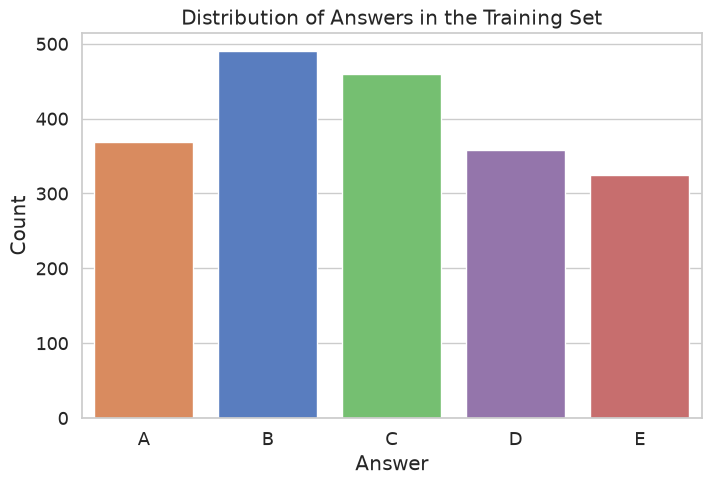

Target proportions:
answer
A    0.1845
B    0.2450
C    0.2295
D    0.1790
E    0.1620
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x='answer', data=train_df, order=['A', 'B', 'C', 'D','E'], hue='answer', legend=False)
plt.title('Distribution of Answers in the Training Set')
plt.xlabel('Answer')
plt.ylabel('Count')
plt.show()

print("Target proportions:")
print(train_df['answer'].value_counts(normalize=True).sort_index())

### Text Length Analysis

In [ ]:
train_df['prompt_length'] = train_df['prompt'].apply(lambda x: len(str(x).split()))

options = ['A', 'B', 'C', 'D', 'E']
for opt in options:
    train_df[f'option_{opt}_length'] = train_df[f'{opt}'].apply(lambda x: len(str(x).split()))

train_df['avg_answer_length'] = train_df[[f'option_{opt}_length' for opt in options]].mean(axis=1)

print("Prompt length statistics:")
print(train_df['prompt_length'].describe())
print("\nAnswer length statistics:")
print(train_df['avg_answer_length'].describe())

Prompt length statistics:
count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: prompt_length, dtype: float64

Answer length statistics:
count    2000.000000
mean       26.279600
std        17.029056
min         1.000000
25%        14.600000
50%        23.000000
75%        36.800000
max        85.400000
Name: avg_answer_length, dtype: float64


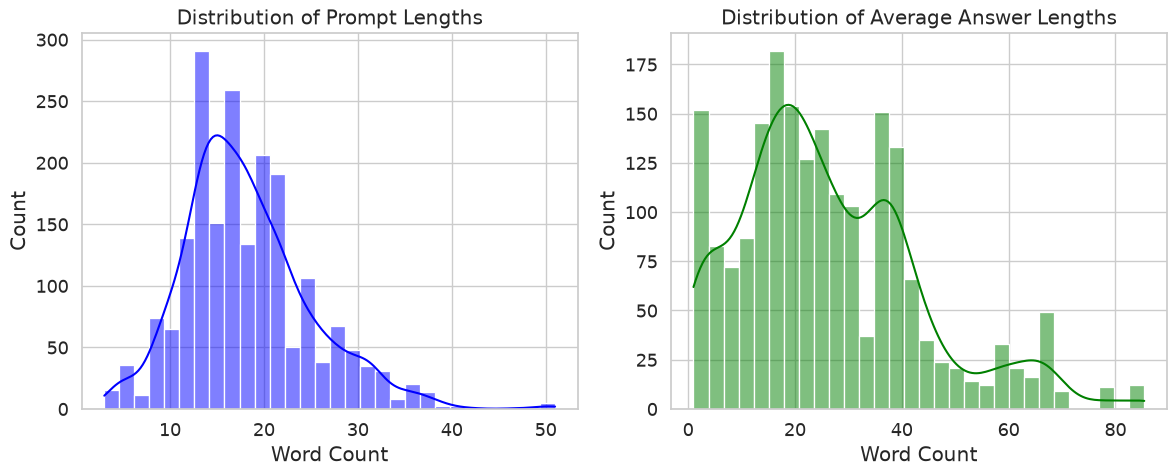

In [12]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_df['prompt_length'], bins=30, kde=True, color='blue')
plt.title('Distribution of Prompt Lengths')
plt.xlabel('Word Count')

plt.subplot(1, 2, 2)
sns.histplot(train_df['avg_answer_length'], bins=30, kde=True, color='green')
plt.title('Distribution of Average Answer Lengths')
plt.xlabel('Word Count')

plt.tight_layout()
plt.show()

### Word Overlaping in 'prompts' with correct and incorrect options

In [13]:
def get_overlap(row, options):
    p_words = set(str(row['prompt']).lower().split())
    o_words = set(str(row[options]).lower().split())
    return len(p_words.intersection(o_words))

overlap_correct = []
overlap_incorrect = []

for idx, row in train_df.iterrows():
    correct_option = row['answer']
    correct_overlap = get_overlap(row, correct_option)
    overlap_correct.append(correct_overlap)
    
    incorrect_options = [opt for opt in options if opt != correct_option]
    incorrect_overlaps = [get_overlap(row, opt) for opt in incorrect_options]
    overlap_incorrect.append(np.mean(incorrect_overlaps))

print("Average overlap with correct answer:", np.mean(overlap_correct))
print("Average overlap with incorrect answers:", np.mean(overlap_incorrect))

Average overlap with correct answer: 4.1095
Average overlap with incorrect answers: 4.152625
